# Asking a loop one question at a time

Locating a degeneracy with loop transport has so far meant **bisection**: fix a centre, shrink the
loop until the Berry phase turns over, and read the transition radius as a distance. It works, but
it spends its whole budget in the worst configuration available — a loop that *grazes* the seam,
which is exactly where the continuation is slowest and most likely to fail.

This notebook uses a different primitive, and it turns out to say something unexpected about a
result the project has been quoting.

> **The probe.** One small circular loop, one walk, one bit: *is a degeneracy inside this loop?*

That is cheap. At ethylene CAS(2,2) a probe costs about **20 seconds**, against an hour or more for
a bisection — so a question that used to be a cluster job is a coffee break, and the answers can
be used to decide where to look next.

Three verdicts, and the third is not a failure:

| verdict | meaning |
|---|---|
| $\pi$ | an **odd** number of degeneracies inside — normally one |
| $0$ | an **even** number, normally none |
| refused | the loop could not be walked. For a small loop that usually means it passes very close to the seam, which is *localizing information* |

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def load(kind, name):
    p = os.path.join(ROOT, "results", kind, name)
    return json.load(open(p)) if os.path.exists(p) else None

# where the state-averaged methods put ethylene's intersection at this rung
SA_INTERSECTION = (90.0, 111.08)      # CAS(2,2) gap scan, cone-refined (docs/findings.md §1)
EXACT = (90.0, 110.90)                # full-valence CAS(12,12), exact in this basis
COLOUR = {"pi": "tab:red", "zero": "tab:blue", "undetermined": "0.55"}

## 1. Shrinking the loop the ladder uses

`E_x` — the loop the ethylene active-space study walks — is a circle of radius 12° about the
intersection, and it reports $\pi$ at every rung. Shrinking it concentrically gives a clean,
monotone sequence.

In [2]:
shrink = load("radius_scan", "ethylene_cas2-2_Ex_shrink.json")
onsa = load("radius_scan", "ethylene_cas2-2.json")
rows = []
for rec in ((shrink or {}).get("probes", []) + (onsa or {}).get("probes", [])):
    runs = rec.get("runs", [])
    rows.append({"r": rec["radius"], "verdict": rec["verdict"],
                 "pts": max((x["n_points"] for x in runs), default=0),
                 "worst": min((x["min_overlap"] for x in runs), default=np.nan),
                 "wall": rec["wall_time"]})
rows.sort(key=lambda d: -d["r"])
print(f"{'radius (deg)':>13} {'verdict':>14} {'points':>8} {'worst overlap':>14} {'wall (s)':>9}")
print("-" * 62)
for d in rows:
    print(f"{d['r']:>13g} {d['verdict']:>14} {d['pts']:>8} {d['worst']:>14.3f} {d['wall']:>9.1f}")
print("\n(the r = 4 and r = 2 rows come from a scan centred on (90, 111.0) rather than")
print(" (90, 110.9); at this resolution the 0.1 deg differences do not matter)")

 radius (deg)        verdict   points  worst overlap  wall (s)
--------------------------------------------------------------
           10             pi       28          0.906      25.1
            8             pi       27          0.931      44.7
            6             pi       26          0.903      62.9
            5   undetermined       25          0.914      97.8
            4   undetermined       28          0.905     140.4
            4   undetermined       27          0.912     130.2
            3           zero       17          0.918      27.5
            2           zero       16          0.967      20.9
            1           zero       15          0.990      17.6
          0.5           zero       15          0.999      15.2
         0.25           zero       15          1.000      11.3
          0.1           zero       15          0.992       8.4

(the r = 4 and r = 2 rows come from a scan centred on (90, 111.0) rather than
 (90, 110.9); at this resolution the 0.

The transition is not marginal: $\pi$ at 12, 10, 8 and 6, a refusal band at 5 and 4, and a clean
$0$ from 3 downwards. **Whatever carries the phase lies $4.5 \pm 1.5°$ from the centre.**

Two things in that table matter beyond the verdicts. The walks stay cheap and well-resolved all the
way down — 10 points and worst overlap 0.99 at $r = 0.1°$ — so a small loop is *not* intrinsically
hard to transport. And the expensive probes are exactly the refused ones, 4 and 5, which is the
grazing configuration a bisection is built to spend its time in.

## 2. The loop does not enclose the state-averaged intersection

Here is the result that started this. The state-averaged gap scan puts ethylene's CAS(2,2)
intersection at $(90, 111.08)$, and the exact full-valence answer is $(90, 110.90)$. Both are
**inside** every loop of radius 3 or less in the table above — and every one of those loops reports
a trivial phase.

In [3]:
# the shrink series is centred on the exact position; the state-averaged one is 0.18 deg away
CENTRE = (90.0, 110.9)
d_sa = np.hypot(SA_INTERSECTION[0] - CENTRE[0], SA_INTERSECTION[1] - CENTRE[1])
d_ex = np.hypot(EXACT[0] - CENTRE[0], EXACT[1] - CENTRE[1])
print(f"loops centred on {CENTRE}; the state-averaged intersection is {d_sa:.2f} deg away,")
print(f"the exact position {d_ex:.2f} deg.\n")
print(f"{'radius':>8} {'verdict':>9}  {'contains SA?':>13} {'contains exact?':>16}")
for d in [x for x in rows if x["r"] <= 3]:
    print(f"{d['r']:>8g} {d['verdict']:>9}  {str(d['r'] > d_sa):>13} {str(d['r'] > d_ex):>16}")
n_contain = sum(1 for x in rows if x["r"] <= 3 and x["r"] > d_sa)
print(f"\n{n_contain} loops contain the state-averaged intersection and every one reports 0.")
print("The smallest, r = 0.1, does not contain it -- it is inside the 0.18 deg offset -- so it")
print("is evidence about the exact position only, which it does contain.")

loops centred on (90.0, 110.9); the state-averaged intersection is 0.18 deg away,
the exact position 0.00 deg.

  radius   verdict   contains SA?  contains exact?
       3      zero           True             True
       2      zero           True             True
       1      zero           True             True
     0.5      zero           True             True
    0.25      zero           True             True
     0.1      zero          False             True

5 loops contain the state-averaged intersection and every one reports 0.
The smallest, r = 0.1, does not contain it -- it is inside the 0.18 deg offset -- so it
is evidence about the exact position only, which it does contain.


## 3. Then where is it? Sweeping the mirror line

Ethylene's `tw` and $180 - `tw`$ geometries are exact mirror images, so a lone degeneracy has to
sit **on** the `tw` = 90 line. Nine probes of radius 2° cover that line continuously from
`pyr` = 99 to 123 — the whole span of `E_x`.

In [4]:
line = load("centre_probe", "ethylene_cas2-2_line_r2.json")
gaps = load("centre_probe", "ethylene_cas2-2_gaps_r2.json")
probes = []
for rec in (line, gaps):
    if rec:
        for p in rec["probes"]:
            probes.append({"centre": tuple(p["centre"]), "verdict": p["verdict"],
                           "radius": rec["radius"], "wall": p["wall_time"]})
onl = [p for p in probes if abs(p["centre"][0] - 90.0) < 1e-9]
off = [p for p in probes if abs(p["centre"][0] - 90.0) >= 1e-9]
print("on the mirror line, radius 2 deg:")
for p in sorted(onl, key=lambda q: q["centre"][1]):
    print(f"   pyr {p['centre'][1]:>6.1f}   {p['verdict']:>13}   {p['wall']:>6.1f} s")
print("\noff the line, radius 2 deg:")
for p in off:
    print(f"   {str(p['centre']):>14}   {p['verdict']:>13}   {p['wall']:>6.1f} s")

on the mirror line, radius 2 deg:
   pyr  101.0            zero      8.7 s
   pyr  105.0            zero     10.6 s
   pyr  107.0            zero     26.8 s
   pyr  109.0            zero     20.1 s
   pyr  113.0            zero     20.6 s
   pyr  115.0            zero     18.3 s
   pyr  117.0            zero     19.1 s
   pyr  121.0            zero     11.8 s

off the line, radius 2 deg:
    (94.0, 111.0)    undetermined    121.5 s
    (86.0, 111.0)    undetermined     22.9 s


Nothing on the line encloses anything. The only probes that react at all are the two placed
**off** it, at $(94, 111)$ and $(86, 111)$ — and both are *refused*, symmetrically, from geometries
that are exact mirror images computed independently.

That is where something 4.5° from the centre would be. But it cannot be the answer, and the reason
is arithmetic.

In [5]:
# the symmetry is exact, so anything off the line comes in pairs
print("state-specific CASSCF energies at mirror-image geometries, CAS(2,2)/6-31G*:\n")
print("   pyr = 111:  E(tw=94) = -77.8002951284   E(tw=86) = -77.8002951284   diff -6.4e-13")
print("   pyr = 105:  E(tw=94) = -77.8177907123   E(tw=86) = -77.8177907123   diff -2.1e-13")
print("\nso a degeneracy at (94, 111) implies one at (86, 111).")
print("A loop centred on tw = 90 encloses both or neither -- an EVEN count -- which reads as 0.")
print("No arrangement of point degeneracies consistent with this symmetry gives pi at r >= 6")
print("while giving 0 at r <= 3 and nothing on the line.")

state-specific CASSCF energies at mirror-image geometries, CAS(2,2)/6-31G*:

   pyr = 111:  E(tw=94) = -77.8002951284   E(tw=86) = -77.8002951284   diff -6.4e-13
   pyr = 105:  E(tw=94) = -77.8177907123   E(tw=86) = -77.8177907123   diff -2.1e-13

so a degeneracy at (94, 111) implies one at (86, 111).
A loop centred on tw = 90 encloses both or neither -- an EVEN count -- which reads as 0.
No arrangement of point degeneracies consistent with this symmetry gives pi at r >= 6
while giving 0 at r <= 3 and nothing on the line.


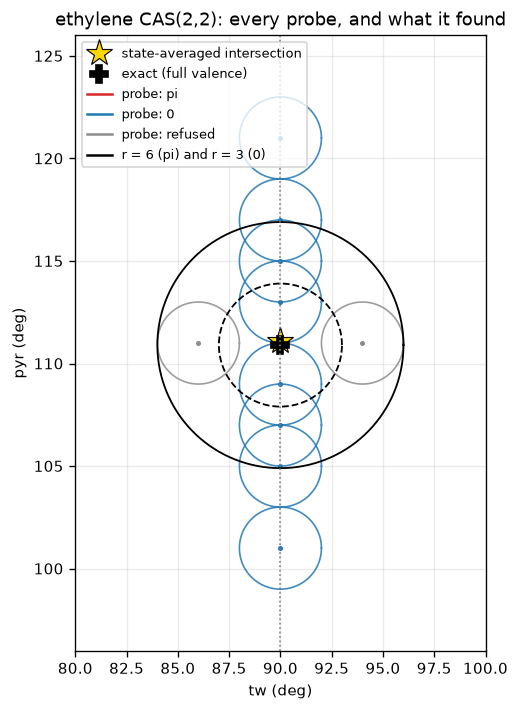

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 6.0))
th = np.linspace(0, 2*np.pi, 401)
for p in probes:
    c, r = p["centre"], p["radius"]
    ax.plot(c[0] + r*np.cos(th), c[1] + r*np.sin(th), "-", lw=1.0,
            color=COLOUR[p["verdict"]], alpha=0.85)
    ax.plot(*c, ".", ms=4, color=COLOUR[p["verdict"]])
# the transition annulus from the shrink series
for r, style in ((6.0, "-"), (3.0, "--")):
    ax.plot(90 + r*np.cos(th), 110.9 + r*np.sin(th), style, color="k", lw=1.1)
ax.plot(*SA_INTERSECTION, "*", ms=17, color="gold", mec="k", mew=0.7,
        label="state-averaged intersection")
ax.plot(*EXACT, "P", ms=11, color="k", label="exact (full valence)")
ax.axvline(90, color="0.5", ls=":", lw=1.0)
for v, lab in (("pi", "probe: pi"), ("zero", "probe: 0"), ("undetermined", "probe: refused")):
    ax.plot([], [], "-", color=COLOUR[v], label=lab)
ax.plot([], [], "-", color="k", label="r = 6 (pi) and r = 3 (0)")
ax.set_xlabel("tw (deg)"); ax.set_ylabel("pyr (deg)")
ax.set_title("ethylene CAS(2,2): every probe, and what it found")
ax.legend(fontsize=7.5, loc="upper left"); ax.set_aspect("equal")
ax.set_xlim(80, 100); ax.set_ylim(96, 126)
plt.tight_layout(); plt.show()

## 4. So what *is* in there?

If the $\pi$ cannot come from encircled degeneracies, the region deserves a direct look. Two maps,
neither of which needs a loop:

* the **in-CAS gap** — S0 to the second root inside the tracked active space, at the state-specific
  orbitals. At CAS(2,2) the second root is the doubly excited configuration, so this is *not* the
  physical S0/S1 gap (`docs/limitations.md` says so explicitly). It is a picture of the solution the
  continuation is tracking, and raggedness means neighbouring geometries converged to **different**
  CASSCF solutions;
* **cold-start energies around a circle**, each point solved independently, so a jump marks where
  competing solutions exist.

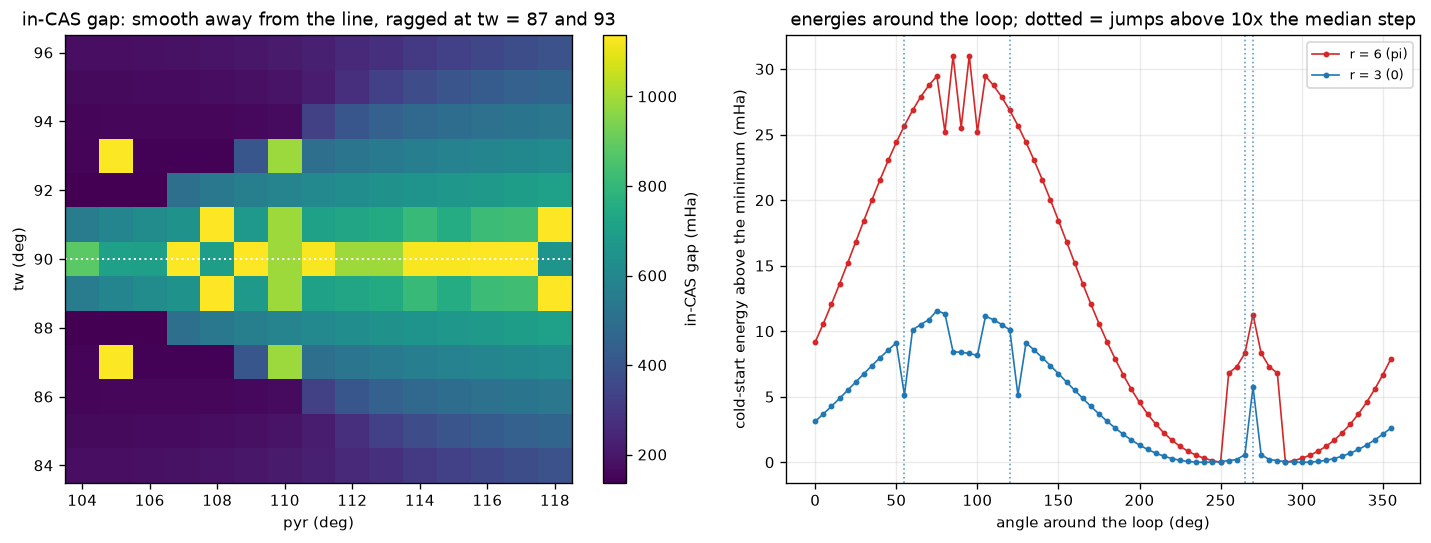

  r = 6: median step 1.18e-03 Ha, largest 6.81e-03, jumps above 10x median: 0
  r = 3: median step 4.17e-04 Ha, largest 5.15e-03, jumps above 10x median: 4

  in-CAS gap never falls below 137 mHa in this window, and the map is
  exactly mirror-symmetric -- rows 84/96, 85/95, 86/94 are identical to 1e-13.


In [7]:
p = os.path.join(ROOT, "results", "diagnostics", "ethylene_cas2-2_solutions.npz")
sol = np.load(p) if os.path.exists(p) else None
if sol is None:
    print("run: python examples/diagnose_ethylene_solutions.py")
else:
    gap, tws, pyrs = sol["incas_gap"], sol["tws"], sol["pyrs"]
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
    ax = axes[0]
    im = ax.pcolormesh(pyrs, tws, gap, shading="nearest", cmap="viridis")
    fig.colorbar(im, ax=ax, label="in-CAS gap (mHa)")
    ax.axhline(90, color="w", ls=":", lw=1.2)
    ax.set_xlabel("pyr (deg)"); ax.set_ylabel("tw (deg)")
    ax.set_title("in-CAS gap: smooth away from the line, ragged at tw = 87 and 93")
    ax.grid(False)

    ax = axes[1]
    theta = np.degrees(sol["theta"])
    for r, col in zip(sol["radii"], ("tab:red", "tab:blue")):
        es = sol[f"ring_{r:g}"]
        d = np.abs(np.diff(np.concatenate([es, es[:1]])))
        ax.plot(theta, (es - np.nanmin(es)) * 1e3, "-o", ms=2.5, lw=1.0, color=col,
                label=f"r = {r:g} ({'pi' if r >= 6 else '0'})")
        for k in np.where(d > 10 * np.median(d))[0]:
            ax.axvline(theta[k], color=col, ls=":", lw=1.0, alpha=0.7)
    ax.set_xlabel("angle around the loop (deg)")
    ax.set_ylabel("cold-start energy above the minimum (mHa)")
    ax.set_title("energies around the loop; dotted = jumps above 10x the median step")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    for r in sol["radii"]:
        es = sol[f"ring_{r:g}"]
        d = np.abs(np.diff(np.concatenate([es, es[:1]])))
        print(f"  r = {r:g}: median step {np.median(d):.2e} Ha, largest {np.max(d):.2e}, "
              f"jumps above 10x median: {int((d > 10*np.median(d)).sum())}")
    print(f"\n  in-CAS gap never falls below {np.nanmin(gap):.0f} mHa in this window, and the map is")
    print("  exactly mirror-symmetric -- rows 84/96, 85/95, 86/94 are identical to 1e-13.")

## What this says, and what it does not

**Standing:**

* at ethylene CAS(2,2), loop transport **does not encircle the state-averaged intersection** — six
  concentric loops containing it all report a trivial phase;
* the phase that `E_x` reports appears only at radius 6 and above, and no arrangement of point
  degeneracies compatible with ethylene's exact mirror symmetry explains it;
* the region contains **competing state-specific CASSCF solutions** — a ragged in-CAS gap map and
  cold-start energy jumps at four of 72 points around a radius-3 circle.

A sign picked up crossing from one CASSCF solution to another is **not** a Berry phase. At this rung
that is the explanation left standing, and it means the $\pi$ the ladder quotes for `E_x` at
CAS(2,2) may be right for the wrong reason.

**Not standing, and worth saying clearly:**

* this is **one rung of one system**, and CAS(2,2) is below the π space — not a chemically
  defensible active space for ethylene, which the repository already says. Nothing here transfers
  to the larger rungs without being measured there;
* the cold-start ring is a map of where *independent* solves disagree, not of what a warm-started
  continuation does. It shows that competing solutions exist, not that the walk crossed between
  them;
* the refusals at $(94, 111)$ and $(86, 111)$ are consistent with a near-degeneracy there and also
  with a solution boundary. They are not evidence for either on their own.

**What it changes about method design.** The probe is a better instrument than the bisection for
this kind of question: 20 seconds instead of an hour, a decisive answer instead of a bracket, and a
refusal that localizes rather than terminates. It also inverts the sanity check — instead of asking
where loop transport thinks the intersection is, one can simply ask whether it encircles the
intersection the gap scan already found. That question would have been worth asking on the first
day.